In [69]:
import pandas as pd

In [70]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [71]:
df["CouponCode"] = df["CouponCode"].fillna(df["CouponCode"].mode()[0])
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [72]:
df["Date"] = pd.to_datetime(df["Date"])

In [73]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayofWeek"] = df["Date"].dt.dayofweek
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayofWeek
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,2
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,4
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,6
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,3


In [74]:
print("********************* BASIC STATISTICS OF DATA ****************************")
print()
df.describe()

********************* BASIC STATISTICS OF DATA ****************************



,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,DayofWeek
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,2023.767500,5.995000,15.969167,3.050833
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,2023.000000,1.000000,1.000000,0.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,2023.000000,3.000000,8.000000,1.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,2024.000000,6.000000,16.000000,3.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,2024.000000,9.000000,24.000000,5.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,2025.000000,12.000000,31.000000,6.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,0.750942,3.344293,8.762450,2.026081


**Year Wise Sales**

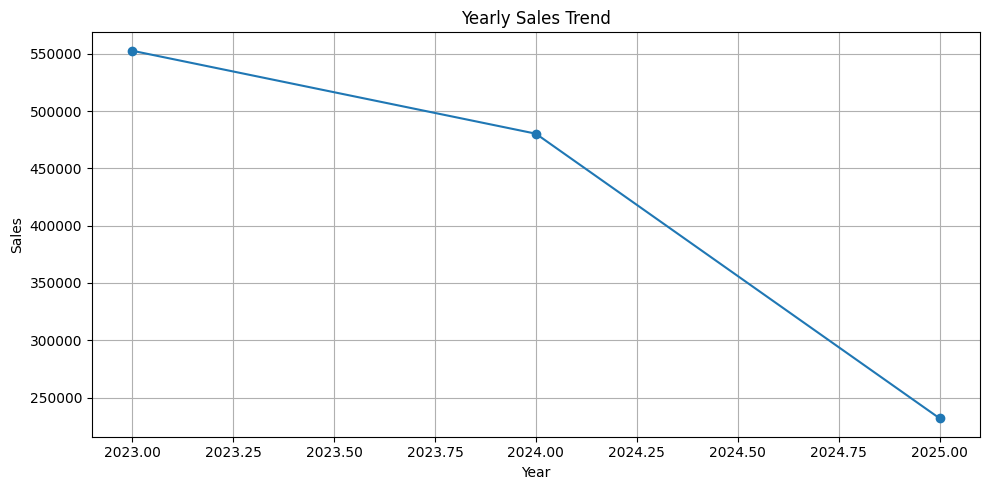

In [75]:
import matplotlib.pyplot as plt
yearly_sales = df.groupby('Year')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Month Wise Sales**

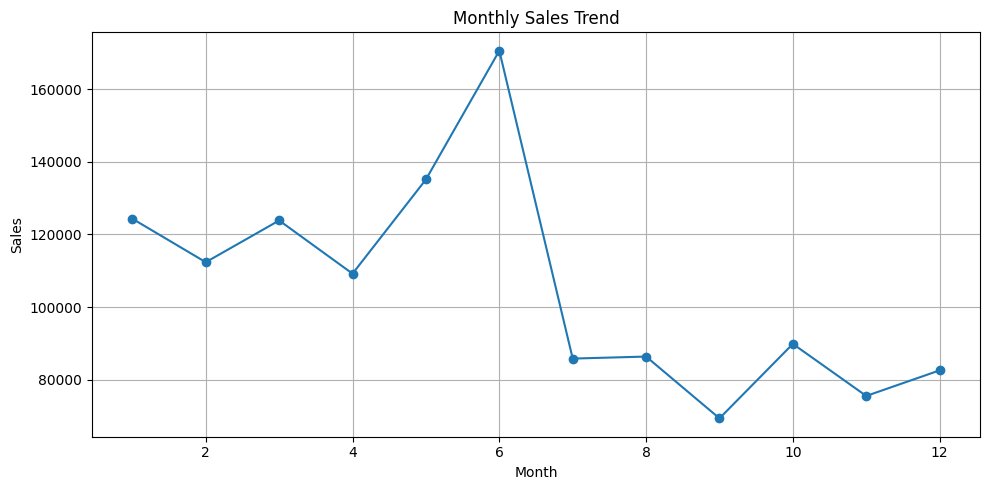

In [76]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Weekdays Wise Sales**

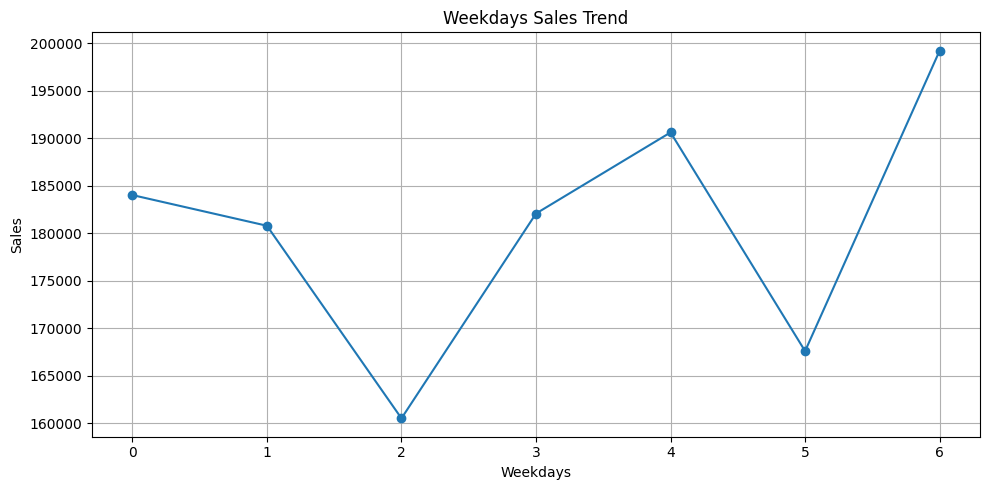

In [77]:
weekdays_sales = df.groupby('DayofWeek')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
weekdays_sales.plot(marker='o')
plt.title("Weekdays Sales Trend")
plt.xlabel("Weekdays")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
# Outliers
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["TotalPrice"] < (Q1 - 1.5 * IQR)) |
    (df["TotalPrice"] > (Q3 + 1.5 * IQR))
]

print("\nNumber of Outliers:", len(outliers))


Number of Outliers: 8


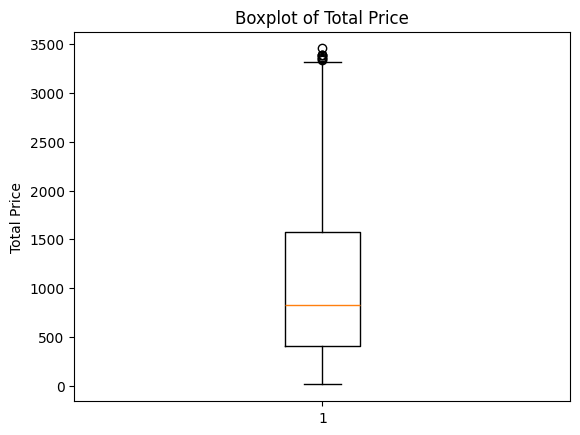

In [81]:
plt.boxplot(df["TotalPrice"])
plt.title("Boxplot of Total Price")
plt.ylabel("Total Price")
plt.show()